In [11]:
import os, random, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

!pip -q install kagglehub
import kagglehub

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [12]:
path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("Descargado en:", path)

# Buscar las carpetas que contienen directamente las carpetas de clases
dirs = [dp for dp, dn, _ in os.walk(path) if 'buildings' in dn]
train_dir = [d for d in dirs if 'train' in d.lower()][0]
test_dir  = [d for d in dirs if 'test'  in d.lower()][0]
print("Train:", train_dir)
print("Test :", test_dir)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Descargado en: /kaggle/input/intel-image-classification
Train: /kaggle/input/intel-image-classification/seg_train/seg_train
Test : /kaggle/input/intel-image-classification/seg_test/seg_test


### 1. Estudio de las características (features) y del rótulo

Clases (rótulos): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'] -> k = 6


,train,test
buildings,2191,437
forest,2271,474
glacier,2404,553
mountain,2512,525
sea,2274,510
street,2382,501
TOTAL,14034,3000


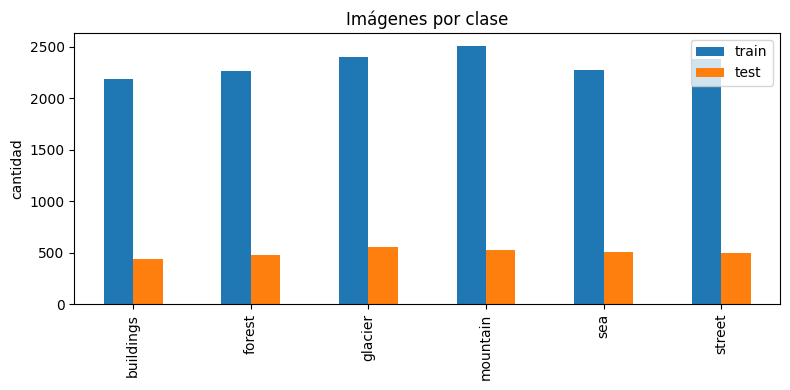

In [13]:
class_names = sorted(os.listdir(train_dir))
print("Clases (rótulos):", class_names, "-> k =", len(class_names))

def contar(d):
    return {c: len(os.listdir(os.path.join(d, c))) for c in class_names}

df = pd.DataFrame({"train": contar(train_dir), "test": contar(test_dir)})
df.loc["TOTAL"] = df.sum()
display(df)

df.drop("TOTAL").plot(kind="bar", figsize=(8,4), title="Imágenes por clase")
plt.ylabel("cantidad"); plt.tight_layout(); plt.show()

In [14]:
# Muestra de imágenes de cada clase
from PIL import Image
fig, axes = plt.subplots(len(class_names), 5, figsize=(12, 14))
sizes = []
for i, c in enumerate(class_names):
    files = random.sample(os.listdir(os.path.join(train_dir, c)), 5)
    for j, f in enumerate(files):
        img = Image.open(os.path.join(train_dir, c, f))
        sizes.append(img.size)
        axes[i, j].imshow(img); axes[i, j].axis("off")
        if j == 0: axes[i, j].set_title(c, loc="left", fontsize=12)
plt.tight_layout(); plt.show()
print("Tamaños de imagen observados (ancho, alto):", set(sizes))

Output hidden; open in https://colab.research.google.com to view.

## 2. Carga de datos y partición
- 80 % entrenamiento / 20 % validación (a partir de `seg_train`).
- Conjunto de prueba separado (`seg_test`) para estimar el comportamiento en el mundo real.
- Todas las imágenes se redimensionan a 150×150.

In [15]:
IMG_SIZE = (150, 150)
BATCH = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset="training", seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH)
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset="validation", seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH, shuffle=False)

assert train_ds.class_names == class_names
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

for xb, yb in train_ds.take(1):
    print("Forma de un lote X:", xb.shape, "| rango de píxeles:", float(tf.reduce_min(xb)), "-", float(tf.reduce_max(xb)))
    print("Forma de un lote Y:", yb.shape, "| ejemplo de rótulos:", yb[:8].numpy())

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Forma de un lote X: (32, 150, 150, 3) | rango de píxeles: 0.0 - 255.0
Forma de un lote Y: (32,) | ejemplo de rótulos: [2 1 4 5 2 3 2 0]


## 3. Modelo (red neuronal convolucional)
Diferencias frente a los ejemplos del capítulo, por ser un problema de 6 clases con imágenes:
- Salida **softmax** (probabilidades que suman 1) y pérdida **entropía cruzada**, en lugar de sigmoide + error cuadrático.
- Capas convolucionales + max pooling para aprender los rasgos locales (bordes, texturas, formas).
- **Dropout** y *data augmentation* para reducir el sobreentrenamiento (overfitting).
- ReLU como función de activación en las capas ocultas.

In [16]:
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
])

model = models.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),
    data_aug,
    layers.Rescaling(1./255),                       # normaliza píxeles a [0,1]
    layers.Conv2D(32, 3, activation="relu"), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"), layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation="relu"), layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu"),
    layers.Dense(len(class_names), activation="softmax"),
])
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Entrenamiento

In [17]:
callbacks = [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4,
                                              restore_best_weights=True)]
history = model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=callbacks)

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.6085 - loss: 1.0201 - val_accuracy: 0.6579 - val_loss: 0.9048
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.7053 - loss: 0.7876 - val_accuracy: 0.7591 - val_loss: 0.6532
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.7490 - loss: 0.6715 - val_accuracy: 0.7619 - val_loss: 0.6333
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.7734 - loss: 0.6185 - val_accuracy: 0.7505 - val_loss: 0.7428
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.7850 - loss: 0.5827 - val_accuracy: 0.7751 - val_loss: 0.6192
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.7975 - loss: 0.5544 - val_accuracy: 0.8097 - val_loss: 0.5275
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.8075 - loss: 0.5179 - val_accuracy: 0.7855 - val_loss: 0.5765
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.8225 - loss: 0.4874 - 

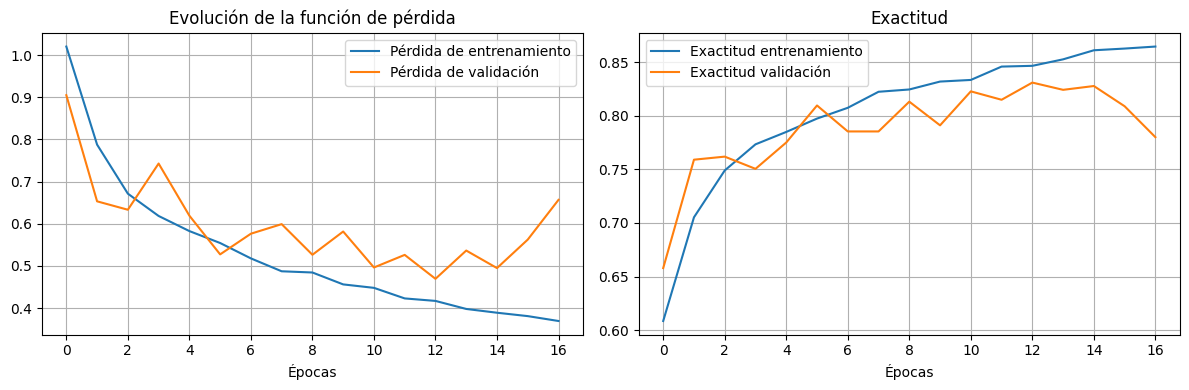

In [18]:
# Evolución de la función de pérdida y de la exactitud (como la figura 5.17 del documento)
h = history.history
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(h["loss"], label="Pérdida de entrenamiento")
ax[0].plot(h["val_loss"], label="Pérdida de validación")
ax[0].set_title("Evolución de la función de pérdida"); ax[0].set_xlabel("Épocas"); ax[0].legend(); ax[0].grid(True)
ax[1].plot(h["accuracy"], label="Exactitud entrenamiento")
ax[1].plot(h["val_accuracy"], label="Exactitud validación")
ax[1].set_title("Exactitud"); ax[1].set_xlabel("Épocas"); ax[1].legend(); ax[1].grid(True)
plt.tight_layout(); plt.show()

## 5. Evaluación con el conjunto de prueba

Exactitud en prueba: 0.842 | Pérdida: 0.468
              precision    recall  f1-score   support

   buildings      0.812     0.842     0.827       437
      forest      0.945     0.973     0.958       474
     glacier      0.788     0.819     0.803       553
    mountain      0.839     0.695     0.760       525
         sea      0.824     0.853     0.838       510
      street      0.850     0.884     0.867       501

    accuracy                          0.842      3000
   macro avg      0.843     0.844     0.842      3000
weighted avg      0.842     0.842     0.840      3000



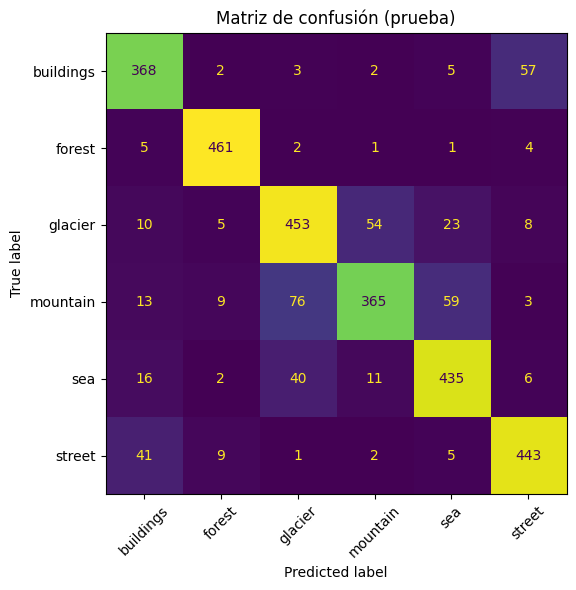

In [19]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Exactitud en prueba: {test_acc:.3f} | Pérdida: {test_loss:.3f}")

y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_pred = np.argmax(model.predict(test_ds, verbose=0), axis=1)

print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=class_names).plot(
    ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Matriz de confusión (prueba)"); plt.tight_layout(); plt.show()